# Explore Silver v=3 Data\n\nRead compacted Parquet files from S3 and inspect the schema.

In [1]:
import boto3
import io
import pyarrow.parquet as pq
import pandas as pd

s3 = boto3.client("s3")
BUCKET = "prediction-markets-data"

def read_silver_v3(event_type: str, date: str) -> pd.DataFrame:
    """Read compacted silver v=3 Parquet for a given event type and date."""
    prefix = f"silver/kalshi_ws/{event_type}/date={date}/v=3/"
    resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)
    keys = [obj["Key"] for obj in resp.get("Contents", []) if obj["Key"].endswith(".parquet")]
    if not keys:
        print(f"No files found at {prefix}")
        return pd.DataFrame()
    
    tables = []
    for k in keys:
        body = s3.get_object(Bucket=BUCKET, Key=k)["Body"].read()
        tables.append(pq.read_table(io.BytesIO(body)))
    
    import pyarrow as pa
    return pa.concat_tables(tables).to_pandas()

## OrderBookUpdate

In [2]:
ob = read_silver_v3("OrderBookUpdate", "2026-04-26")
print(f"Shape: {ob.shape}")
print(f"\nDtypes:\n{ob.dtypes}")
print(f"\nHead:")
ob.head(10)

Shape: (4954335, 9)

Dtypes:
t_receipt_ns        int64
t_exchange_ns     float64
market_ticker    category
bid_yes             int32
ask_yes             int32
bid_size            int32
ask_size            int32
sid                 int32
seq                 int32
dtype: object

Head:


,t_receipt_ns,t_exchange_ns,market_ticker,bid_yes,ask_yes,bid_size,ask_size,sid,seq
0,1777170981089049600,NaN,KXNBAGAME-26APR25DENMIN-DEN,55,56,9863,5828,1,1
1,1777170981089286656,NaN,KXNBAGAME-26APR25DENMIN-MIN,44,45,72604,40844,1,2
2,1777170981091144192,NaN,KXNBAGAME-26APR26BOSPHI-BOS,73,74,32399,247578,1,3
3,1777170981091334656,NaN,KXNBAGAME-26APR26BOSPHI-PHI,26,27,98130,177357,1,4
4,1777170981101744896,NaN,KXNBAGAME-26APR26CLETOR-CLE,60,61,23841,204155,1,5
5,1777170981102040832,NaN,KXNBASPREAD-26APR25DENMIN-DEN11,10,12,401,501,2,1
6,1777170981102158080,NaN,KXNBAGAME-26APR26CLETOR-TOR,39,40,19259,17757,1,6
7,1777170981102341632,NaN,KXNBASPREAD-26APR25DENMIN-DEN14,5,7,68,300,2,2
8,1777170981102481152,NaN,KXNBAGAME-26APR26LALHOU-HOU,61,62,32677,18492,1,7
9,1777170981102644736,NaN,KXNBASPREAD-26APR25DENMIN-DEN17,2,3,232,550,2,3


## TradeEvent

In [3]:
trades = read_silver_v3("TradeEvent", "2026-04-26")
print(f"Shape: {trades.shape}")
print(f"\nDtypes:\n{trades.dtypes}")
print(f"\nHead:")
trades.head(10)

Shape: (1193678, 8)

Dtypes:
t_receipt_ns        int64
t_exchange_ns       int64
market_ticker    category
side             category
price               int32
size                int32
sid                 int32
seq                 int32
dtype: object

Head:


,t_receipt_ns,t_exchange_ns,market_ticker,side,price,size,sid,seq
0,1777161556926844416,1777161556000000000,KXNBAGAME-26APR25NYKATL-NYK,no,96,26,4,127462
1,1777161557278649088,1777161557000000000,KXNBATOTAL-26APR25NYKATL-208,no,28,20,4,127463
2,1777161557447127040,1777161557000000000,KXNBAGAME-26APR25DENMIN-DEN,yes,52,37,4,127464
3,1777161557528493568,1777161557000000000,KXNBAPTS-26APR25NYKATL-NYKJBRUNSON11-20,yes,60,6,4,127465
4,1777161557629059072,1777161557000000000,KXNBAGAME-26APR25NYKATL-NYK,no,96,2,4,127466
5,1777161557852726784,1777161557000000000,KXNBAGAME-26APR25DENMIN-DEN,yes,52,37,4,127467
6,1777161557955401728,1777161557000000000,KXNBAGAME-26APR25NYKATL-ATL,no,3,396,4,127468
7,1777161557971565824,1777161557000000000,KXNBATOTAL-26APR25NYKATL-208,no,28,182,4,127469
8,1777161558119977472,1777161558000000000,KXNBASPREAD-26APR25NYKATL-NYK2,no,93,112,4,127470
9,1777161558120204288,1777161558000000000,KXNBASPREAD-26APR25NYKATL-NYK2,no,93,604,4,127471


## MMFillEvent

In [4]:
fills = read_silver_v3("MMFillEvent", "2026-04-26")
print(f"Shape: {fills.shape}")
print(f"\nDtypes:\n{fills.dtypes}")
print(f"\nHead:")
fills.head(10)

Shape: (448, 11)

Dtypes:
t_receipt_ns               int64
market_ticker           category
side                    category
price                      int32
fill_size                  int32
order_remaining_size       int32
position_before            int32
position_after             int32
maker_fee                  int32
order_id                     str
book_mid_at_fill           int32
dtype: object

Head:


,t_receipt_ns,market_ticker,side,price,fill_size,order_remaining_size,position_before,position_after,maker_fee,order_id,book_mid_at_fill
0,1777161565171942144,KXNBAPTS-26APR25NYKATL-NYKKTOWNS32-15,buy,69,1,0,0,1,1,paper-52283,0
1,1777161571090477568,KXNBAPTS-26APR25NYKATL-ATLOOKONGWU17-10,sell,73,1,0,0,-1,1,paper-52311,0
2,1777161598991067904,KXNBAPTS-26APR25NYKATL-NYKKTOWNS32-15,buy,63,1,0,1,2,1,paper-52403,0
3,1777161621155176960,KXNBAPTS-26APR25NYKATL-NYKJHART3-15,sell,35,1,0,0,-1,1,paper-52487,0
4,1777161823313049088,KXNBAPTS-26APR25NYKATL-ATLCMCCOLLUM3-25,buy,23,1,0,-1,0,1,paper-52967,0
5,1777161829738935296,KXNBAPTS-26APR25NYKATL-ATLJJOHNSON1-15,sell,73,1,0,0,-1,1,paper-52982,0
6,1777161996210719232,KXNBAPTS-26APR25NYKATL-NYKKTOWNS32-15,sell,99,1,0,2,1,1,paper-53357,0
7,1777162129981808384,KXNBAPTS-26APR25NYKATL-NYKJBRUNSON11-25,buy,1,1,0,5,6,1,paper-51093,0
8,1777162182941332992,KXNBAPTS-26APR25NYKATL-NYKJBRUNSON11-25,buy,1,1,0,6,7,1,paper-53909,0
9,1777162197117702144,KXNBAPTS-26APR25NYKATL-NYKKTOWNS32-20,sell,77,1,0,1,0,1,paper-54127,0


## Deep Dive: Pick a Random Market

Pick one market from 4/26, pull its metadata, BBO timeline, and trades to verify everything lines up.

In [5]:
# What tickers were active on 4/26?
tickers_ob = ob["market_ticker"].value_counts()
tickers_tr = trades["market_ticker"].value_counts()
print(f"Unique tickers in OrderBookUpdate: {len(tickers_ob)}")
print(f"Unique tickers in TradeEvent: {len(tickers_tr)}")
print(f"\nTop 10 by BBO updates:")
print(tickers_ob.head(10))
print(f"\nTop 10 by trades:")
print(tickers_tr.head(10))

Unique tickers in OrderBookUpdate: 452
Unique tickers in TradeEvent: 478

Top 10 by BBO updates:
market_ticker
KXNBAGAME-26APR26CLETOR-TOR               334512
KXNBAGAME-26APR26CLETOR-CLE               292079
KXNBAGAME-26APR26SASPOR-SAS               277981
KXNBAGAME-26APR26SASPOR-POR               243456
KXNBAGAME-26APR28PORSAS-SAS               126478
KXNBAGAME-26APR26BOSPHI-PHI               115847
KXNBAPTS-26APR26SASPOR-PORSSHARPE17-10    109302
KXNBAPTS-26APR26SASPOR-PORJGRANT9-15      107910
KXNBAGAME-26APR25DENMIN-DEN               104107
KXNBAGAME-26APR25DENMIN-MIN               102409
Name: count, dtype: int64

Top 10 by trades:
market_ticker
KXNBAGAME-26APR25DENMIN-MIN       128528
KXNBAGAME-26APR26SASPOR-SAS       109408
KXNBAGAME-26APR26CLETOR-TOR        91856
KXNBAGAME-26APR25DENMIN-DEN        85400
KXNBAGAME-26APR26CLETOR-CLE        78820
KXNBAGAME-26APR26SASPOR-POR        76530
KXNBAGAME-26APR26BOSPHI-PHI        61514
KXNBAGAME-26APR26LALHOU-LAL        57558
KXNBAGAME-26

In [6]:
# Pick a game-level market — DEN vs MIN Game 4, Denver side
# Ticker date is the game date (APR25), not the data date (APR26)
TICKER = "KXNBAGAME-26APR25DENMIN-DEN"

# Pull metadata
from pyarrow import fs as afs
meta_table = pq.read_table(
    "prediction-markets-data/reference/kalshi_markets.parquet",
    filesystem=afs.S3FileSystem(region="us-east-1"),
)
meta = meta_table.to_pandas()
m = meta[meta["ticker"] == TICKER].iloc[0]
print("=== Market Metadata ===")
for col in ["ticker", "series_ticker", "event_ticker", "title", "yes_sub_title", 
            "no_sub_title", "status", "result", "open_time", "close_time", 
            "settlement_time", "volume", "last_price_cents", "settlement_value_cents"]:
    print(f"  {col}: {m[col]}")

=== Market Metadata ===
  ticker: KXNBAGAME-26APR25DENMIN-DEN
  series_ticker: KXNBAGAME
  event_ticker: KXNBAGAME-26APR25DENMIN
  title: Game 4: Denver at Minnesota Winner?
  yes_sub_title: Denver
  no_sub_title: Denver
  status: finalized
  result: no
  open_time: 2026-04-15 21:29:00+00:00
  close_time: 2026-04-26 03:24:33+00:00
  settlement_time: 2026-04-26 03:25:10.288911+00:00
  volume: 20442580
  last_price_cents: 1
  settlement_value_cents: 0.0


In [7]:
# BBO timeline for this ticker
ob_t = ob[ob["market_ticker"] == TICKER].copy()
ob_t["time"] = pd.to_datetime(ob_t["t_receipt_ns"], unit="ns", utc=True)
ob_t["spread"] = ob_t["ask_yes"] - ob_t["bid_yes"]
ob_t["mid"] = (ob_t["bid_yes"] + ob_t["ask_yes"]) / 2

print(f"=== BBO for {TICKER} ===")
print(f"Rows: {len(ob_t)}")
print(f"Time range: {ob_t['time'].min()} → {ob_t['time'].max()}")
print(f"\nSpread distribution (cents):")
print(ob_t["spread"].describe())
print(f"\nBid/Ask range: bid {ob_t['bid_yes'].min()}-{ob_t['bid_yes'].max()}, ask {ob_t['ask_yes'].min()}-{ob_t['ask_yes'].max()}")
print(f"\nFirst 10 rows:")
ob_t[["time", "bid_yes", "ask_yes", "bid_size", "ask_size", "spread"]].head(10)

=== BBO for KXNBAGAME-26APR25DENMIN-DEN ===
Rows: 104107
Time range: 2026-04-26 02:36:21.089049600+00:00 → 2026-04-26 03:10:23.609555712+00:00

Spread distribution (cents):
count    104107.000000
mean          1.433371
std           0.806724
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          12.000000
Name: spread, dtype: float64

Bid/Ask range: bid 1-63, ask 2-66

First 10 rows:


,time,bid_yes,ask_yes,bid_size,ask_size,spread
0,2026-04-26 02:36:21.089049600+00:00,55,56,9863,5828,1
381,2026-04-26 02:36:21.168494336+00:00,55,56,9931,5828,1
382,2026-04-26 02:36:21.168542976+00:00,55,56,9931,5799,1
385,2026-04-26 02:36:21.168736768+00:00,55,56,9931,5749,1
395,2026-04-26 02:36:21.301580544+00:00,55,56,9438,5749,1
398,2026-04-26 02:36:21.347063808+00:00,55,56,9438,10981,1
400,2026-04-26 02:36:21.348001280+00:00,55,56,9438,10981,1
401,2026-04-26 02:36:21.371588096+00:00,55,56,9396,10981,1
402,2026-04-26 02:36:21.379457024+00:00,55,56,9396,10889,1
411,2026-04-26 02:36:21.456577536+00:00,55,56,19762,10889,1


In [8]:
# Trades for this ticker
tr_t = trades[trades["market_ticker"] == TICKER].copy()
tr_t["time"] = pd.to_datetime(tr_t["t_receipt_ns"], unit="ns", utc=True)
tr_t["t_exchange"] = pd.to_datetime(tr_t["t_exchange_ns"], unit="ns", utc=True)

print(f"=== Trades for {TICKER} ===")
print(f"Rows: {len(tr_t)}")
print(f"Time range: {tr_t['time'].min()} → {tr_t['time'].max()}")
print(f"\nBy side:")
print(tr_t.groupby("side").agg(trades=("size", "count"), total_size=("size", "sum"), avg_price=("price", "mean")).round(1))
print(f"\nPrice distribution:")
print(tr_t["price"].describe())
print(f"\nLatency (receipt - exchange) seconds:")
latency = (tr_t["t_receipt_ns"] - tr_t["t_exchange_ns"]) / 1e9
print(latency.describe())
print(f"\nFirst 15 trades:")
tr_t[["time", "side", "price", "size"]].head(15)

=== Trades for KXNBAGAME-26APR25DENMIN-DEN ===
Rows: 85400
Time range: 2026-04-25 23:59:17.447127040+00:00 → 2026-04-26 03:24:31.540964096+00:00

By side:
      trades  total_size  avg_price
side                               
no     17418     9508568       40.5
yes    67982    25382564       43.4

Price distribution:
count    85400.000000
mean        42.842506
std         24.558226
min          1.000000
25%         17.000000
50%         53.000000
75%         60.000000
max         85.000000
Name: price, dtype: float64

Latency (receipt - exchange) seconds:
count    85400.000000
mean         0.533195
std          0.287533
min          0.024904
25%          0.286184
50%          0.531307
75%          0.780969
max          1.568465
dtype: float64

First 15 trades:


,time,side,price,size
2,2026-04-25 23:59:17.447127040+00:00,yes,52,37
5,2026-04-25 23:59:17.852726784+00:00,yes,52,37
14,2026-04-25 23:59:18.848274176+00:00,yes,52,167
49,2026-04-25 23:59:20.711417344+00:00,yes,52,92
54,2026-04-25 23:59:20.985740544+00:00,yes,52,50
108,2026-04-25 23:59:24.774994176+00:00,yes,52,742
144,2026-04-25 23:59:26.761985536+00:00,yes,52,563
183,2026-04-25 23:59:29.654245888+00:00,yes,52,8
216,2026-04-25 23:59:32.963716352+00:00,yes,52,46
227,2026-04-25 23:59:33.528476928+00:00,yes,52,19


In [9]:
# Sanity checks
print("=== Sanity Checks ===\n")

# 1. Trade prices should be within BBO (or at least close)
ob_first_bid = ob_t.iloc[0]["bid_yes"]
ob_first_ask = ob_t.iloc[0]["ask_yes"]
print(f"1. First BBO snapshot: bid={ob_first_bid}, ask={ob_first_ask}")

# 2. Trades vs BBO: asof merge to find BBO at time of each trade
ob_sorted = ob_t[["t_receipt_ns", "bid_yes", "ask_yes"]].sort_values("t_receipt_ns")
tr_sorted = tr_t[["t_receipt_ns", "price", "side", "size"]].sort_values("t_receipt_ns")
merged = pd.merge_asof(tr_sorted, ob_sorted, on="t_receipt_ns", direction="backward")
merged["inside_spread"] = (merged["price"] >= merged["bid_yes"]) & (merged["price"] <= merged["ask_yes"])
merged["at_bid"] = merged["price"] == merged["bid_yes"]
merged["at_ask"] = merged["price"] == merged["ask_yes"]
print(f"2. Trades at bid: {merged['at_bid'].sum()} ({merged['at_bid'].mean()*100:.1f}%)")
print(f"   Trades at ask: {merged['at_ask'].sum()} ({merged['at_ask'].mean()*100:.1f}%)")
print(f"   Trades inside spread: {merged['inside_spread'].sum()} ({merged['inside_spread'].mean()*100:.1f}%)")
outside = ~merged["inside_spread"] & ~merged["at_bid"] & ~merged["at_ask"]
print(f"   Trades outside BBO: {outside.sum()} ({outside.mean()*100:.1f}%)")

# 3. Settlement consistency
print(f"\n3. Settlement: result={m['result']}, last_price={m['last_price_cents']}c, settlement_value={m['settlement_value_cents']}c")
if m["result"] == "yes":
    print("   DEN won → YES settled at 100c" if m["settlement_value_cents"] == 100 else "   ✗ Unexpected settlement value")
elif m["result"] == "no":
    print("   DEN lost → YES settled at 0c" if m["settlement_value_cents"] == 0 else "   ✗ Unexpected settlement value")

# 4. Crossed books
crossed = ob_t[ob_t["bid_yes"] >= ob_t["ask_yes"]]
print(f"\n4. Crossed book snapshots: {len(crossed)} ({len(crossed)/len(ob_t)*100:.2f}%)")

# 5. t_exchange_ns coverage on BBO
has_exchange = ob_t["t_exchange_ns"].notna().sum()
print(f"\n5. BBO rows with t_exchange_ns: {has_exchange}/{len(ob_t)} ({has_exchange/len(ob_t)*100:.1f}%)")

=== Sanity Checks ===

1. First BBO snapshot: bid=55, ask=56
2. Trades at bid: 10058 (11.8%)
   Trades at ask: 30498 (35.7%)
   Trades inside spread: 43948 (51.5%)
   Trades outside BBO: 41452 (48.5%)

3. Settlement: result=no, last_price=1c, settlement_value=0.0c
   DEN lost → YES settled at 0c

4. Crossed book snapshots: 0 (0.00%)

5. BBO rows with t_exchange_ns: 104105/104107 (100.0%)


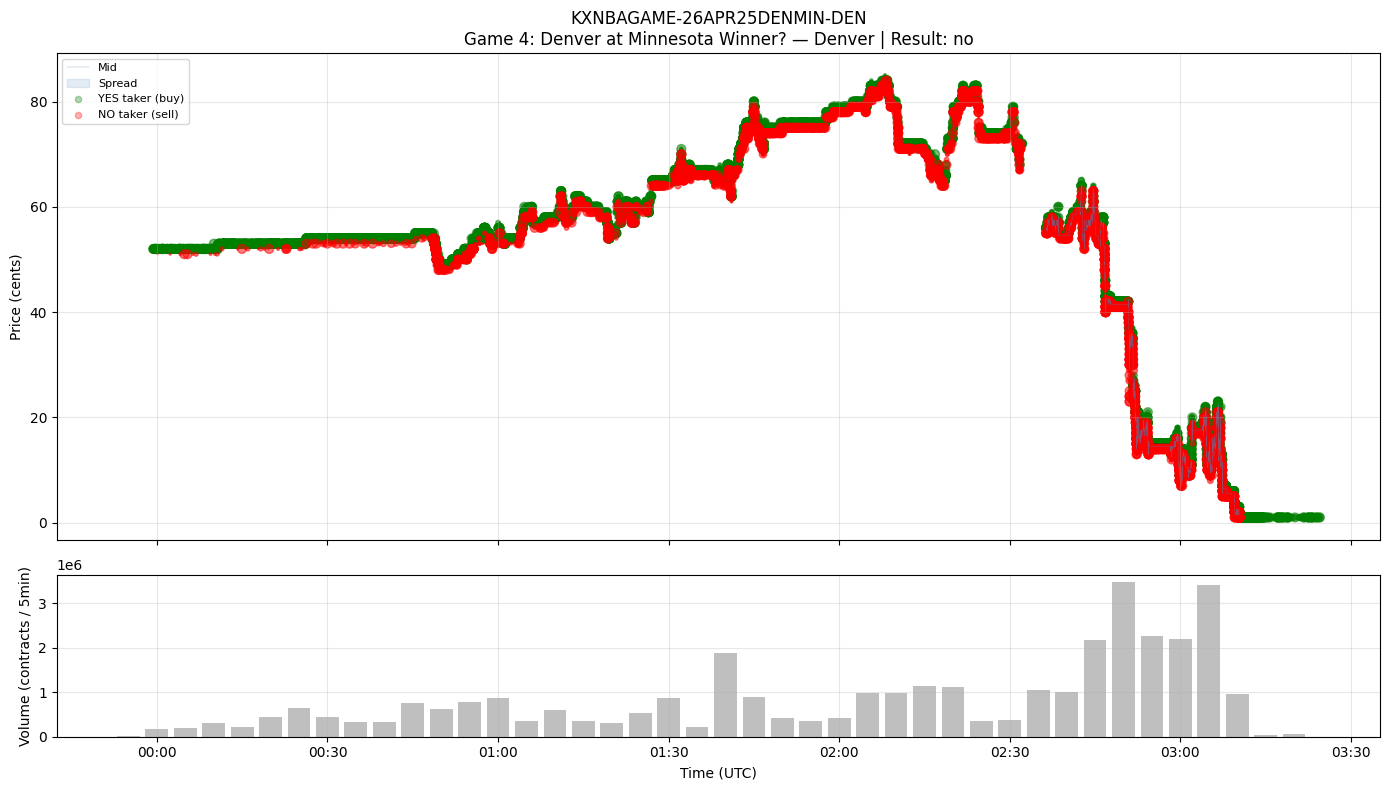

In [10]:
# Price chart: mid price over time with trades overlaid
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# BBO mid price
ax1.plot(ob_t["time"], ob_t["mid"], linewidth=0.3, color="steelblue", alpha=0.6, label="Mid")
ax1.fill_between(ob_t["time"], ob_t["bid_yes"], ob_t["ask_yes"], alpha=0.15, color="steelblue", label="Spread")

# Trades colored by side
yes_trades = tr_t[tr_t["side"] == "yes"]
no_trades = tr_t[tr_t["side"] == "no"]
ax1.scatter(yes_trades["time"], yes_trades["price"], s=yes_trades["size"].clip(upper=200)/5, 
            c="green", alpha=0.3, label="YES taker (buy)")
ax1.scatter(no_trades["time"], no_trades["price"], s=no_trades["size"].clip(upper=200)/5,
            c="red", alpha=0.3, label="NO taker (sell)")

ax1.set_ylabel("Price (cents)")
ax1.set_title(f"{TICKER}\n{m['title']} — {m['yes_sub_title']} | Result: {m['result']}")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)

# Volume bars (5-min buckets)
tr_t_copy = tr_t.set_index("time")
vol = tr_t_copy.resample("5min")["size"].sum().fillna(0)
ax2.bar(vol.index, vol.values, width=pd.Timedelta(minutes=4), color="gray", alpha=0.5)
ax2.set_ylabel("Volume (contracts / 5min)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=ob_t["time"].dt.tz))
ax2.set_xlabel("Time (UTC)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()